Data loaded successfully. Shape: (284807, 31)
Training set shape: (227845, 30), Test set shape: (56962, 30)

TASK 1: ANOMALY DETECTION (UNSUPERVISED)

--- Isolation Forest Results ---
Accuracy : 0.9976
Precision: 0.3048
Recall   : 0.3265
F1-Score : 0.3153

Training One-Class SVM on a subsample of normal transactions...

--- One-Class SVM Results ---
Accuracy : 0.9731
Precision: 0.0519
Recall   : 0.8469
F1-Score : 0.0979

TASK 2: HYPERPARAMETER TUNING (Random Forest)
Running RandomizedSearchCV on Random Forest... (This may take a minute)
Best parameters found:
{'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'class_weight': 'balanced'}

--- Tuned Random Forest Results ---
Accuracy : 0.9994
Precision: 0.8404
Recall   : 0.8061
F1-Score : 0.8229
ROC-AUC  : 0.9521
PR-AUC   : 0.7898

TASK 3: DEEP LEARNING AUTOENCODER
Training MLPRegressor as an Autoencoder...
Calculated MSE threshold for fraud detection: 2.1734

--- Autoencoder (MLPRegressor) Results ---

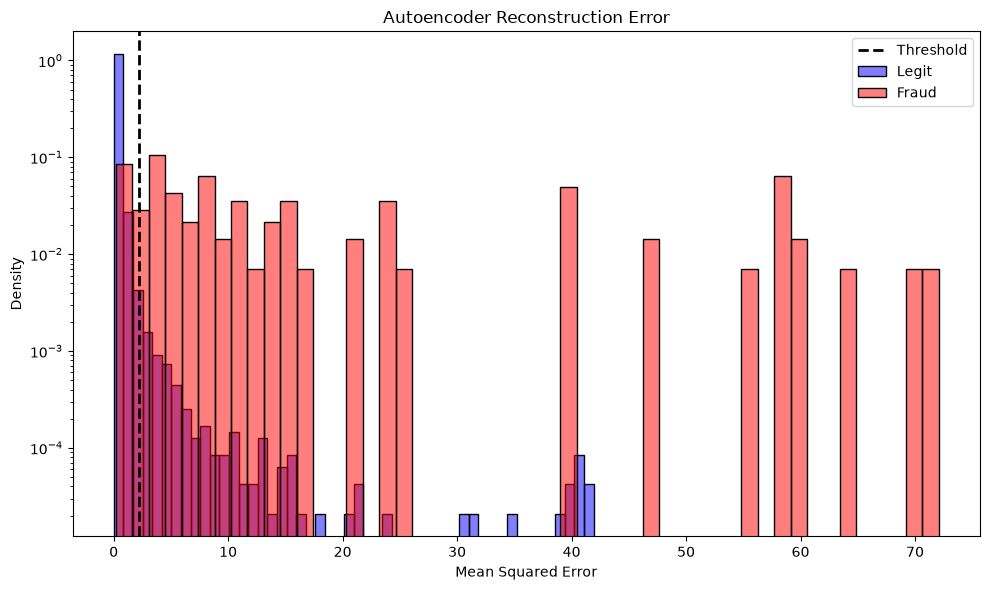

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. Data Loading and Preprocessing
# ---------------------------------------------------------
filepath = 'dataset/creditcard.csv'
if not os.path.exists(filepath):
    print(f"Error: Dataset not found at {filepath}")
    exit()

df = pd.read_csv(filepath)
print("Data loaded successfully. Shape:", df.shape)

scaler = StandardScaler()
df['Scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

# Function to evaluate models
def evaluate_model(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n--- {name} Results ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc = auc(fpr, tpr)
        precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_proba)
        pr_auc = auc(recall_vals, precision_vals)
        print(f"ROC-AUC  : {roc_auc:.4f}")
        print(f"PR-AUC   : {pr_auc:.4f}")
        
    return f1

# ---------------------------------------------------------
# 2. Extension: Anomaly Detection (Unsupervised)
# ---------------------------------------------------------
print("\n" + "="*50)
print("TASK 1: ANOMALY DETECTION (UNSUPERVISED)")
print("="*50)

# We use the entire training set (without labels) for Isolation Forest
iso_forest = IsolationForest(n_estimators=100, max_samples='auto', contamination=float(sum(y_train==1))/len(y_train), random_state=42)
iso_forest.fit(X_train)

# Predict returns 1 for inliers, -1 for outliers
# We map it to: 0 for inliers (legit), 1 for outliers (fraud)
y_pred_iso = iso_forest.predict(X_test)
y_pred_iso = np.where(y_pred_iso == 1, 0, 1)

evaluate_model("Isolation Forest", y_test, y_pred_iso)

# One-Class SVM can be very slow on large datasets, so we train it only on a subsample of NORMAL transactions
print("\nTraining One-Class SVM on a subsample of normal transactions...")
X_train_normal = X_train[y_train == 0]
# Subsample for speed (e.g., 20000 samples)
sample_idx = np.random.choice(X_train_normal.index, size=20000, replace=False)
X_train_normal_sample = X_train_normal.loc[sample_idx]

ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.001)
ocsvm.fit(X_train_normal_sample)

y_pred_ocsvm = ocsvm.predict(X_test)
y_pred_ocsvm = np.where(y_pred_ocsvm == 1, 0, 1)

evaluate_model("One-Class SVM", y_test, y_pred_ocsvm)

# ---------------------------------------------------------
# 3. Extension: Hyperparameter Tuning
# ---------------------------------------------------------
print("\n" + "="*50)
print("TASK 2: HYPERPARAMETER TUNING (Random Forest)")
print("="*50)

# We use a randomized search to optimize Random Forest for the F1 score.
# To speed this up, we'll use a stratified subsample of the training data.
X_train_sub, _, y_train_sub, _ = train_test_split(X_train, y_train, test_size=0.8, random_state=42, stratify=y_train)

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

print("Running RandomizedSearchCV on Random Forest... (This may take a minute)")
random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=0, 
    random_state=42
)

random_search.fit(X_train_sub, y_train_sub)
print("Best parameters found:")
print(random_search.best_params_)

best_rf = random_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

evaluate_model("Tuned Random Forest", y_test, y_pred_rf, y_proba_rf)

# ---------------------------------------------------------
# 4. Extension: Deep Learning Autoencoder using MLPRegressor
# ---------------------------------------------------------
print("\n" + "="*50)
print("TASK 3: DEEP LEARNING AUTOENCODER")
print("="*50)

# An Autoencoder predicts its input.
# We train it ONLY on normal transactions so it learns to reconstruct them well.
# Fraudulent transactions should yield a higher reconstruction error (MSE).

print("Training MLPRegressor as an Autoencoder...")
# Define network architecture: Input(29) -> 14 -> 7 -> 14 -> Output(29)
autoencoder = MLPRegressor(
    hidden_layer_sizes=(14, 7, 14),
    activation='relu',
    solver='adam',
    max_iter=50, 
    random_state=42,
    early_stopping=True,
    verbose=False
)

# Train on normal transactions only
autoencoder.fit(X_train_normal, X_train_normal)

# Predict on test set
X_test_pred = autoencoder.predict(X_test)

# Calculate Mean Squared Error (reconstruction error) for each instance
mse = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

# The threshold can be set using the 99.5th percentile of training MSE (or tuned via validation set)
X_train_normal_pred = autoencoder.predict(X_train_normal)
train_mse = np.mean(np.power(X_train_normal - X_train_normal_pred, 2), axis=1)
threshold = np.percentile(train_mse, 99.5) # Allow 0.5% of normal transactions to be flagged as fraud

print(f"Calculated MSE threshold for fraud detection: {threshold:.4f}")

# Classify instances with MSE > threshold as fraud (1)
y_pred_ae = (mse > threshold).astype(int)

evaluate_model("Autoencoder (MLPRegressor)", y_test, y_pred_ae)

# Plot Reconstruction Error distribution
plt.figure(figsize=(10, 6))
sns.histplot(mse[y_test == 0], bins=50, color='blue', alpha=0.5, label='Legit', stat='density')
sns.histplot(mse[y_test == 1], bins=50, color='red', alpha=0.5, label='Fraud', stat='density')
plt.axvline(threshold, color='k', linestyle='dashed', linewidth=2, label='Threshold')
plt.title('Autoencoder Reconstruction Error')
plt.xlabel('Mean Squared Error')
plt.ylabel('Density')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('autoencoder_error.png')
print("\nReconstruction error plot saved to autoencoder_error.png")
